In [1]:
import pandas as pd
import numpy as np


In [2]:
loan_train = pd.read_csv('./data/train.csv')

In [3]:
loan_train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [4]:
print("Rows, Columns:", loan_train.shape)

Rows, Columns: (58645, 13)


In [5]:
loan_train.columns.tolist()

['id',
 'person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length',
 'loan_status']

In [6]:
loan_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [7]:
loan_train.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [8]:
print("Number of duplicate rows:", loan_train.duplicated().sum())


Number of duplicate rows: 0


In [9]:
loan_train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [10]:
categorical_cols = loan_train.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [11]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(loan_train[col].value_counts())
    print()

--- person_home_ownership ---
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: person_home_ownership, dtype: int64

--- loan_intent ---
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: loan_intent, dtype: int64

--- loan_grade ---
A    20984
B    20400
C    11036
D     5034
E     1009
F      149
G       33
Name: loan_grade, dtype: int64

--- cb_person_default_on_file ---
N    49943
Y     8702
Name: cb_person_default_on_file, dtype: int64



In [12]:
print(loan_train["loan_status"].value_counts())


0    50295
1     8350
Name: loan_status, dtype: int64


In [13]:
print(loan_train.groupby('loan_status')['loan_int_rate'].mean())
print(loan_train.groupby('loan_status')['loan_grade'].value_counts(normalize=True).unstack())
print(loan_train.groupby('loan_status')['cb_person_default_on_file'].value_counts(normalize=True).unstack())

loan_status
0    10.258767
1    13.202305
Name: loan_int_rate, dtype: float64
loan_grade          A         B         C         D         E         F  \
loan_status                                                               
0            0.396699  0.364112  0.189721  0.040680  0.007516  0.001153   
1            0.123593  0.249940  0.178922  0.357844  0.075569  0.010898   

loan_grade          G  
loan_status            
0            0.000119  
1            0.003234  
cb_person_default_on_file         N         Y
loan_status                                  
0                          0.878696  0.121304
1                          0.688503  0.311497


In [14]:
!pip install seaborn

In [15]:
!pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: /opt/homebrew/lib/python3.11/site-packages
Requires: matplotlib, numpy, pandas
Required-by: 


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

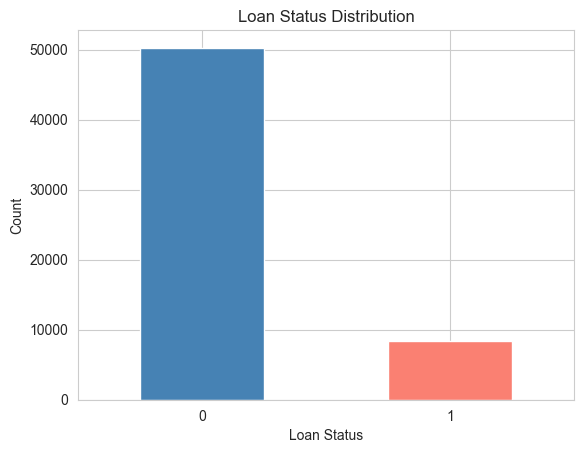

In [17]:
loan_train["loan_status"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

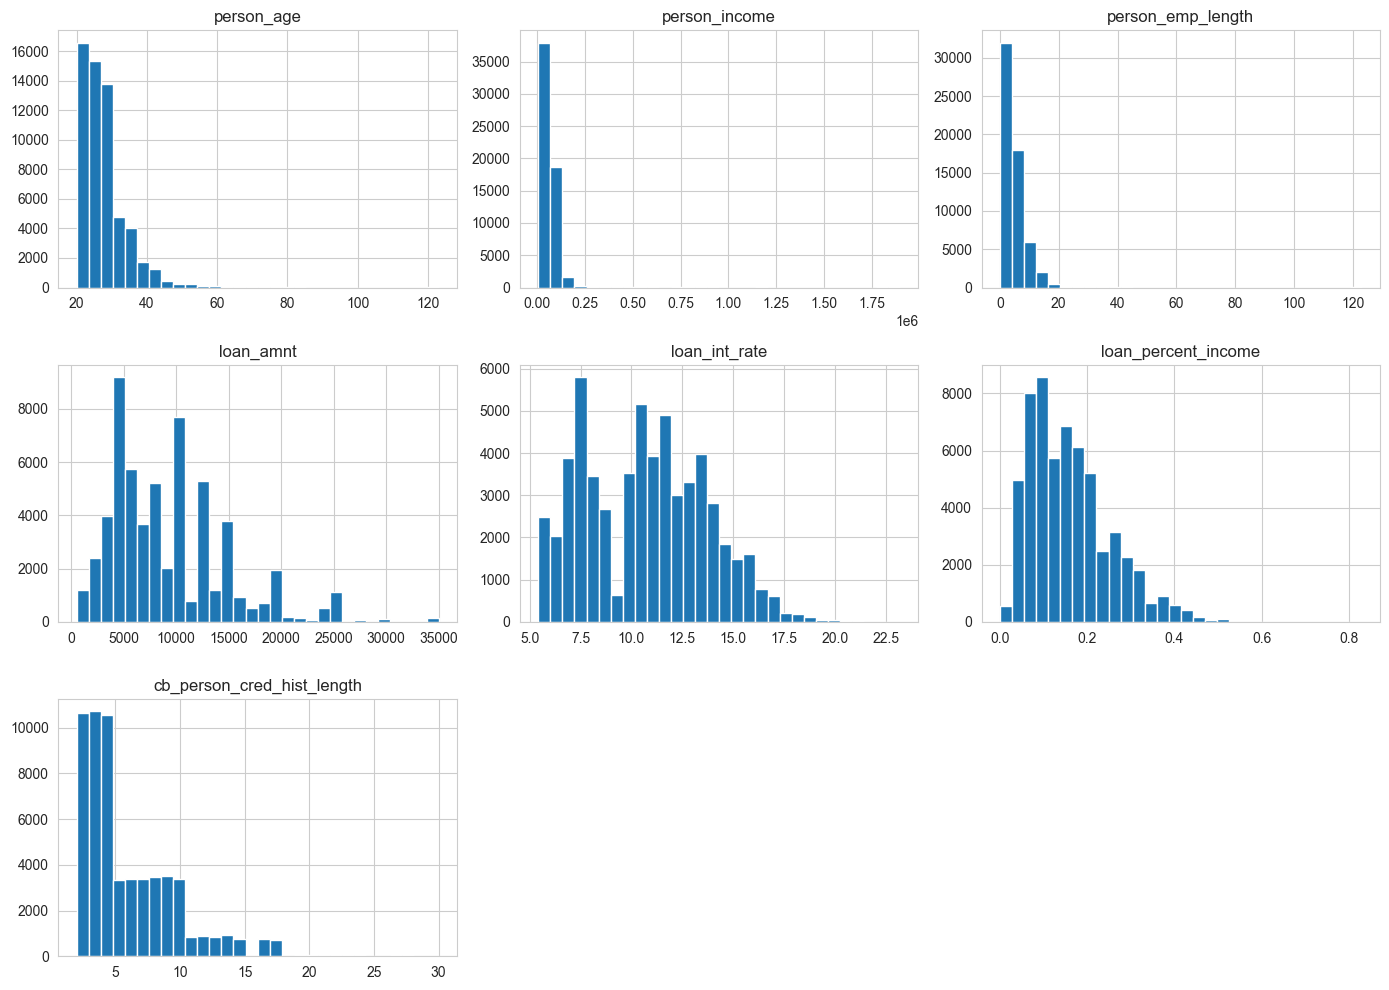

In [18]:
numeric_cols = ["person_age", "person_income", "person_emp_length",
                "loan_amnt", "loan_int_rate", "loan_percent_income",
                "cb_person_cred_hist_length"]

loan_train[numeric_cols].hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

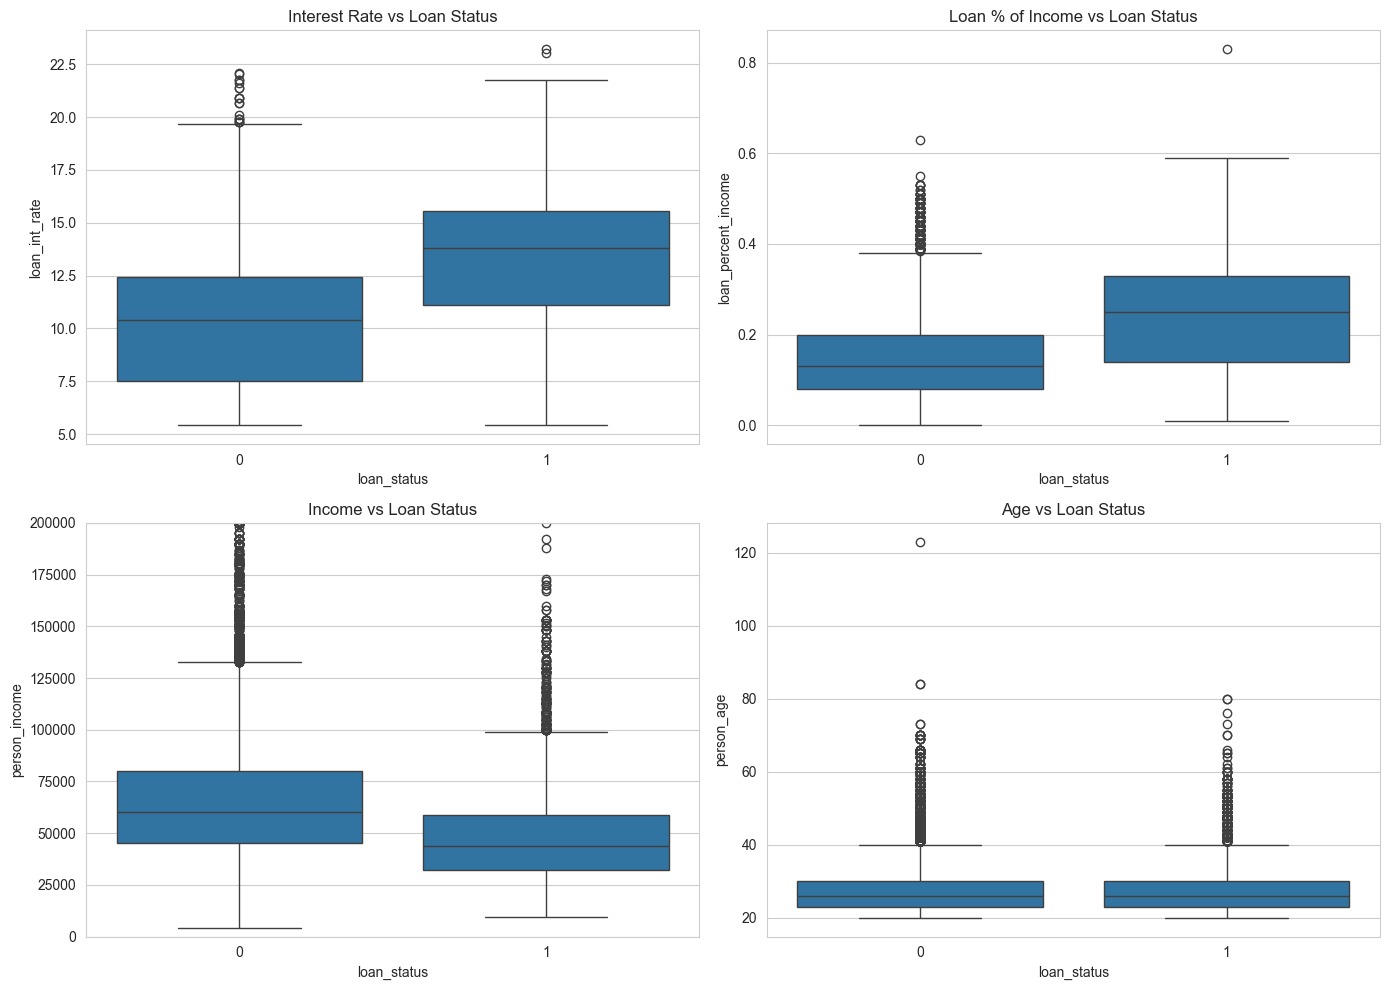

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=loan_train, x="loan_status", y="loan_int_rate", ax=axes[0, 0])
axes[0, 0].set_title("Interest Rate vs Loan Status")

sns.boxplot(data=loan_train, x="loan_status", y="loan_percent_income", ax=axes[0, 1])
axes[0, 1].set_title("Loan % of Income vs Loan Status")

sns.boxplot(data=loan_train, x="loan_status", y="person_income", ax=axes[1, 0])
axes[1, 0].set_title("Income vs Loan Status")
axes[1, 0].set_ylim(0, 200000)  # zoom in, income has extreme outliers

sns.boxplot(data=loan_train, x="loan_status", y="person_age", ax=axes[1, 1])
axes[1, 1].set_title("Age vs Loan Status")

plt.tight_layout()
plt.show()

In [20]:
for col in ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]:
    print(f"--- Default rate by {col} ---")
    print(loan_train.groupby(col)["loan_status"].mean().round(3).sort_values(ascending=False))
    print()


--- Default rate by person_home_ownership ---
person_home_ownership
RENT        0.223
OTHER       0.169
MORTGAGE    0.060
OWN         0.014
Name: loan_status, dtype: float64

--- Default rate by loan_intent ---
loan_intent
DEBTCONSOLIDATION    0.189
MEDICAL              0.178
HOMEIMPROVEMENT      0.174
PERSONAL             0.133
EDUCATION            0.108
VENTURE              0.093
Name: loan_status, dtype: float64

--- Default rate by loan_grade ---
loan_grade
G    0.818
E    0.625
F    0.611
D    0.594
C    0.135
B    0.102
A    0.049
Name: loan_status, dtype: float64

--- Default rate by cb_person_default_on_file ---
cb_person_default_on_file
Y    0.299
N    0.115
Name: loan_status, dtype: float64



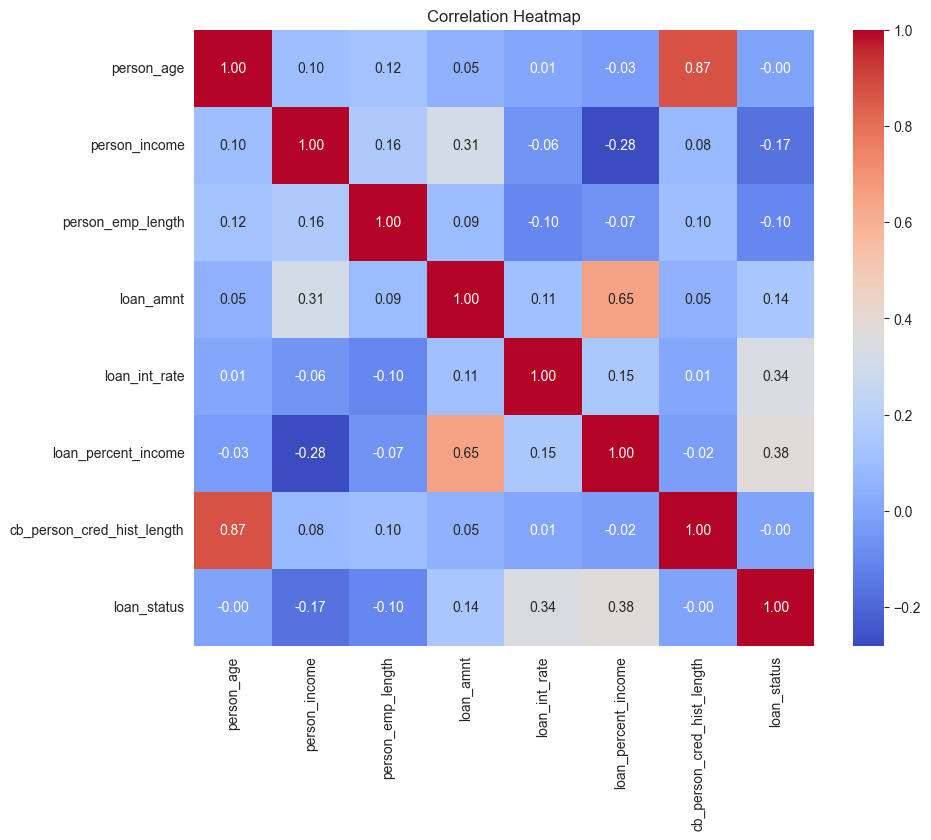

In [21]:
plt.figure(figsize=(10, 8))
corr = loan_train[numeric_cols + ["loan_status"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
print("Max age:", loan_train["person_age"].max())
print("Max employment length:", loan_train["person_emp_length"].max())
print("Rows where emp_length looks impossible (>= age):")
print(loan_train[loan_train["person_emp_length"] >= loan_train["person_age"]].shape[0])

Max age: 123
Max employment length: 123.0
Rows where emp_length looks impossible (>= age):
2


In [23]:
age_median = loan_train['person_age'].median()  # compute from train, apply to test
loan_train.loc[loan_train['person_age'] > 100, 'person_age'] = age_median

emp_median = loan_train['person_emp_length'].median()
loan_train.loc[loan_train['person_emp_length'] > 60, 'person_emp_length'] = emp_median

## Regression

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [25]:
X_train = loan_train.drop(columns=['id', 'loan_status'])
y_train = loan_train['loan_status']

In [26]:
X_train = pd.get_dummies(X_train, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [28]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [29]:
print('Model trained on', X_train.shape[0], 'rows and', X_train.shape[1], 'features')

Model trained on 58645 rows and 22 features


In [30]:
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(coefficients.head(10))

                       feature  coefficient
5          loan_percent_income     1.179428
17                loan_grade_D     0.651828
8    person_home_ownership_OWN    -0.650435
4                loan_int_rate     0.579815
9   person_home_ownership_RENT     0.430238
14         loan_intent_VENTURE    -0.393247
1                person_income    -0.322174
3                    loan_amnt    -0.311133
18                loan_grade_E     0.266072
10       loan_intent_EDUCATION    -0.248063


## Test data

In [31]:
laon_test = pd.read_csv('./data/train.csv')

In [32]:
laon_test.loc[laon_test['person_age'] > 100, 'person_age'] = age_median
laon_test.loc[laon_test['person_emp_length'] > 60, 'person_emp_length'] = emp_median

In [33]:
test_ids = laon_test['id']
X_test = laon_test.drop(columns=['id'])

In [34]:
X_test = pd.get_dummies(X_test, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

In [35]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [36]:
X_test_scaled = scaler.transform(X_test)

In [37]:
predictions = model.predict(X_test_scaled)     
prediction_probs = model.predict_proba(X_test_scaled)[:, 1]

In [38]:
results = pd.DataFrame({
    'id': test_ids,
    'loan_status_predicted': predictions,
    'default_probability': prediction_probs.round(4)
})

In [39]:
print(results.head(10))
print()
print('Predicted default rate:', (predictions.mean() * 100).round(2), '%')

   id  loan_status_predicted  default_probability
0   0                      0               0.4248
1   1                      0               0.0084
2   2                      0               0.0233
3   3                      0               0.1710
4   4                      0               0.1350
5   5                      0               0.2549
6   6                      0               0.2152
7   7                      1               0.5158
8   8                      1               0.7713
9   9                      0               0.1502

Predicted default rate: 24.91 %


# Testing Accuracy

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [41]:
train_df = pd.read_csv('./Data/train.csv')

# 2. Clean the known bad values
clean_age = train_df.loc[train_df['person_age'] <= 100, 'person_age'].median()
clean_emp = train_df.loc[train_df['person_emp_length'] <= 60, 'person_emp_length'].median()
train_df.loc[train_df['person_age'] > 100, 'person_age'] = clean_age
train_df.loc[train_df['person_emp_length'] > 60, 'person_emp_length'] = clean_emp

# 3. Separate features (X) from target (y)
X = train_df.drop(columns=['id', 'loan_status'])
y = train_df['loan_status']

# 4. One-hot encode categorical columns
X = pd.get_dummies(X, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

# 5. Split train.csv itself into a training chunk and a "fake test" chunk
#    stratify=y keeps the 86/14 class balance the same in both pieces
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Scale - fit on the training chunk only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 7. Train the model on the training chunk
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 8. Predict on the held-out chunk (X_val) - this is data the model never saw
y_val_pred = model.predict(X_val_scaled)
y_val_proba = model.predict_proba(X_val_scaled)[:, 1]

# 9. Get the accuracy number and full picture
print('Accuracy:', accuracy_score(y_val, y_val_pred).round(4))
print()
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_val_pred))
print()
print('Classification Report:')
print(classification_report(y_val, y_val_pred))
print()
print('ROC-AUC Score:', roc_auc_score(y_val, y_val_proba).round(4))

Accuracy: 0.8453

Confusion Matrix:
[[8521 1538]
 [ 277 1393]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90     10059
           1       0.48      0.83      0.61      1670

    accuracy                           0.85     11729
   macro avg       0.72      0.84      0.75     11729
weighted avg       0.90      0.85      0.86     11729


ROC-AUC Score: 0.9068


# XG BOOST

In [42]:
!pip install xgboost


In [43]:
from xgboost import XGBClassifier

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /opt/homebrew/lib/python3.11/site-packages
Requires: numpy, scipy
Required-by: 
